# 04 — Proportional-integral

**The integrator works out the answer you computed by hand in notebook 01.**

Notebook 03 ended with a specification rather than a complaint. A proportional controller
cannot hold a steady output at zero input, so it cannot settle on a setpoint that costs torque
to hold. What the loop needs is something that **keeps producing an output after the input that
justified it has gone** — something with a memory.

The integral term is that something, and this notebook is mostly one plot. We run the same
90 to 110 km/h step with the integral path switched on, watch the error go to zero, and then
look inside the controller at what the integrator is holding. It settles at 40.119 N.m, which
is the torque the force balance in notebook 01 said it takes to hold 110 km/h, worked out on
paper before any of this ran.

The integrator was never given that number, or the force balance, or the car's mass. It found
it.

## Setup

Same bootstrap as every notebook in this set. The torque ceiling stays lifted — assume for now
an engine that delivers whatever we ask; notebook 06 removes that assumption.

In [1]:
isdefined(Main, :Lecture01Support) || include("support.jl")

# Bound by hand rather than with `using`. If this kernel ever ran an earlier `include` of
# support.jl there are two copies of the module, every name both export is ambiguous, and no
# amount of re-running `using` resolves it. An explicit binding does, so this cell repairs a
# kernel in that state instead of needing it restarted. Editing support.jl still needs a
# restart, because the guard above deliberately will not load a second copy.
for n in names(Lecture01Support)
    n === :Lecture01Support && continue
    Core.eval(Main, :($n = Lecture01Support.$n))
end

In [2]:
setup()

Main.VehicleSystemsComponents

## 1. Adding memory

$$
u(t) \;=\; k\left[\,e(t) \;+\; \frac{1}{T_i}\int_0^{t} e(\tau)\,d\tau\,\right]
$$

The proportional term is unchanged. The new term is an accumulation: every moment of error
adds to a running total, and that total keeps contributing to the command long after the moment
that added it has passed.

Read the integral as a rule about *when it stops changing* rather than as an area.

- While the error is positive the sum grows, so the command grows.
- While the error is negative the sum shrinks, so the command shrinks.
- **The sum stops changing only when the error is exactly zero.**

That last line is the whole mechanism, and it is worth being precise about what it does and does
not promise. It does not say the loop will arrive. It says that *if* the loop settles anywhere,
it can only settle where the error is zero — because anywhere else the integrator is still
moving, so the command is still moving, so nothing has settled.

`T_i`, the integral time, sets how fast the sum accumulates: small `T_i` means an aggressive
integrator. It is a time in seconds, and section 5 is about choosing it.

In Dyad this is `Lecture1.CruiseLoop` with `with_I = true`. The derivative stays off. Nothing
else changes — same car, same step, same gain — so anything different in the plot below is the
integral and nothing else.

P    settled 109.2899   km/h    error 0.7101    km/h    overshoot 39.0 %
PI   settled 110.0001   km/h    error -0.0001   km/h    overshoot 44.1 %


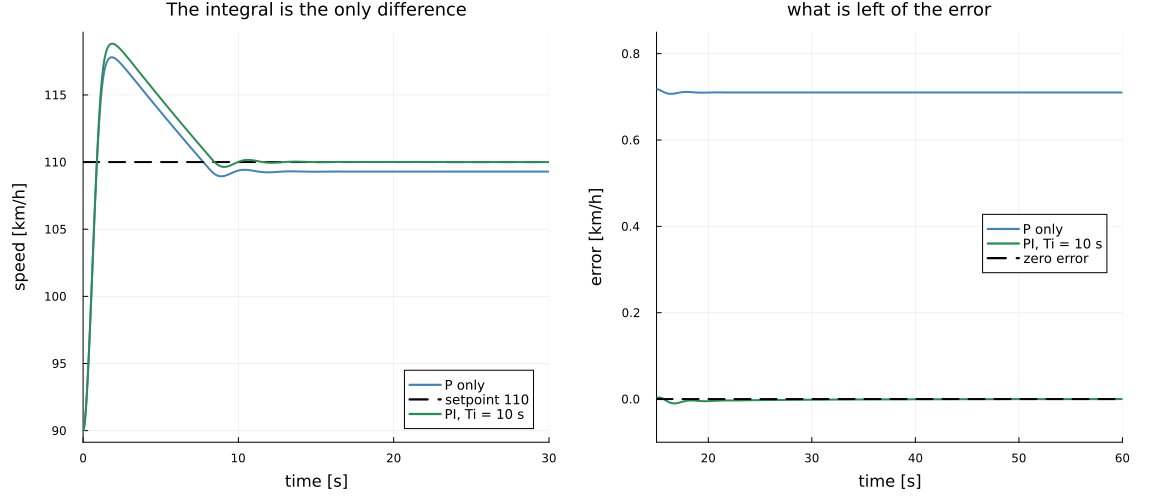

In [3]:
Scenarios = VehicleSystemsComponents.Lecture1

SPEED = "loop.plant.v_kmh"
INTEGRAL = "loop.controller.integrator.y"    # the integrator's state, before the gain k
SETPOINT = 110.0                             # km/h
GAIN = 56.0                                  # N.m per km/h
T_I = 10.0                                   # s
UNLIMITED = 1.0e6                            # N.m

# `with_I` is a structural parameter: the integrator is either built into the equations or it
# is not there at all, so P and PI are two compiled models rather than one model with a
# parameter set to zero.
p_only = Scenarios.CruiseLoopTransient(
    k = GAIN, T_max = UNLIMITED, y_max = UNLIMITED, stop = 60.0)
pi_loop = Scenarios.CruiseLoopTransient(
    model = Scenarios.CruiseLoopStep(; name = :CruiseLoopStep, with_I = true, with_D = false),
    k = GAIN, Ti = T_I, T_max = UNLIMITED, y_max = UNLIMITED, stop = 60.0)

for (name, run) in (("P ", p_only), ("PI", pi_loop))
    println(name, "   settled ", rpad(round(signal(run, SPEED)[2][end], digits = 4), 10),
            " km/h    error ", rpad(round(steady_state_error(run, SETPOINT; sig = SPEED), digits = 4), 9),
            " km/h    overshoot ", round(overshoot(run, SETPOINT; sig = SPEED), digits = 1), " %")
end

# The gap the integral closes is 0.71 km/h on a 20 km/h step, which is invisible on an axis
# that has to show the step as well. Hence the second panel.
step = plot_speed(p_only; sig = SPEED, setpoint = SETPOINT, label = "P only",
                  title = "The integral is the only difference", color = :steelblue,
                  xlims = (0, 30), legend = :bottomright)
plot!(step, signal(pi_loop, SPEED)...; label = "PI, Ti = 10 s", lw = 2, color = :seagreen)

# The second panel plots the error itself rather than the speed. At this magnification the PI
# curve and the setpoint are the same line, and a plot in which the interesting curve is hidden
# underneath the reference it reached is a poor way to show that it reached it.
error_of(run) = (signal(run, SPEED)[1], SETPOINT .- signal(run, SPEED)[2])

arrival = plot(error_of(p_only)...; label = "P only", lw = 2, color = :steelblue,
               xlabel = "time [s]", ylabel = "error [km/h]", title = "what is left of the error",
               xlims = (15, 60), ylims = (-0.1, 0.85), legend = :right)
plot!(arrival, error_of(pi_loop)...; label = "PI, Ti = 10 s", lw = 2, color = :seagreen)
hline!(arrival, [0.0]; ls = :dash, lw = 2, color = :black, label = "zero error")

p_vs_pi = plot(step, arrival; layout = (1, 2), size = (1150, 500))
save_figure(p_vs_pi, "04-p-vs-pi")
p_vs_pi

**The green curve reaches the setpoint.** Not approximately, not to within a tuning tolerance —
it settles at 110.000 km/h and stays there, and it would do the same on a hill, with a full boot,
into a headwind. The 0.71 km/h that proportional control could not close is gone, and no gain
was changed to close it.

**It is not free.** The PI response overshoots further than the P response did and takes longer
to settle down afterwards. Section 5 is about that trade, and section 6 about where it comes
from. For now, notice only that the two curves are barely distinguishable for the first second: the
integrator starts at zero and has accumulated nothing yet, so early in the step a PI controller
*is* a P controller. Everything that distinguishes them happens later.

## 2. What is the integrator holding?

The interesting question is not whether the error went to zero. Section 1 promised that, and an
integrator that stops moving only at zero error is not a surprising thing to discover at zero
error.

The interesting question is what the loop is *doing* when it gets there. The error is zero, so
the proportional term contributes exactly nothing — `k · 0`. But the car is holding 110 km/h
against drag and rolling resistance, so something is commanding about 40 N.m.

That something is the integrator, and we can go and look at it. The plot below is its state over
time, multiplied by `k` so it reads in N.m and can be compared against a number computed on
paper. The dashed line is that number: the cruise torque at 110 km/h from the force balance in
notebook 01, which came from the mass, the drag area and the gear ratio, and never went anywhere
near a controller.

force balance, on paper      T_cruise(110 km/h) = 40.1193 N.m
integrator, at the end of the run           k*I = 40.1194 N.m
difference                                      = 0.0001 N.m


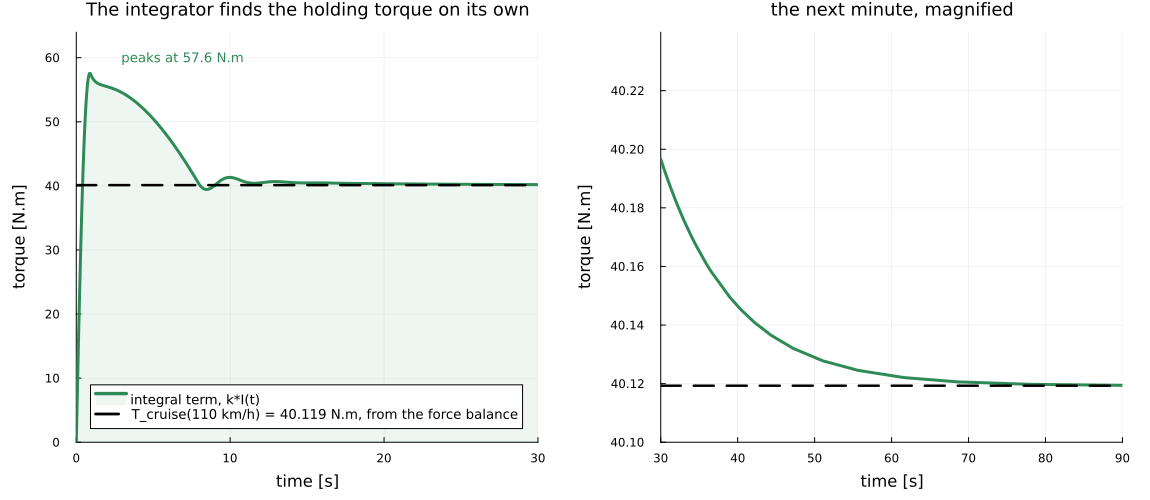

In [4]:
c_drag = 0.5 * CAR.rho * CAR.CdA                            # N per (m/s)^2
F_roll = CAR.f_r * CAR.m * CAR.g                            # N, flat road
cruise_torque(kmh) = (c_drag * (kmh / 3.6)^2 + F_roll) * CAR.r / CAR.i

T_hold = cruise_torque(SETPOINT)

# A longer window than the step needs: the last few hundredths of a N.m take most of a minute
# to arrive, and the point of this plot is exactly where the curve ends up.
settling = Scenarios.CruiseLoopTransient(
    model = Scenarios.CruiseLoopStep(; name = :CruiseLoopStep, with_I = true, with_D = false),
    k = GAIN, Ti = T_I, T_max = UNLIMITED, y_max = UNLIMITED, stop = 90.0)

t, integral = signal(settling, INTEGRAL)
torque = GAIN .* integral

println("force balance, on paper      T_cruise(110 km/h) = ", round(T_hold, digits = 4), " N.m")
println("integrator, at the end of the run           k*I = ", round(torque[end], digits = 4), " N.m")
println("difference                                      = ",
        round(abs(torque[end] - T_hold), digits = 4), " N.m")

climb = plot(t, torque;
    lw = 3, color = :seagreen, fillrange = 0, fillalpha = 0.08, label = "integral term, k*I(t)",
    xlabel = "time [s]", ylabel = "torque [N.m]", xlims = (0, 30), ylims = (0, 64),
    legend = :bottomright, title = "The integrator finds the holding torque on its own")
hline!(climb, [T_hold]; ls = :dash, lw = 2.5, color = :black,
       label = "T_cruise(110 km/h) = $(round(T_hold, digits = 3)) N.m, from the force balance")
annotate!(climb, 3.0, maximum(torque) + 2.5,
          Plots.text("peaks at $(round(maximum(torque), digits = 1)) N.m", 9, :left, :seagreen))

magnified = plot(t, torque;
    lw = 3, color = :seagreen, label = "", xlims = (30, 90), ylims = (40.10, 40.24),
    xlabel = "time [s]", ylabel = "torque [N.m]", title = "the next minute, magnified")
hline!(magnified, [T_hold]; ls = :dash, lw = 2.5, color = :black, label = "")

integrator_state = plot(climb, magnified; layout = (1, 2), size = (1150, 500))
save_figure(integrator_state, "04-integrator-state")
integrator_state

## 3. What that means

**The integrator performed the model inversion from notebook 01.**

That notebook took the force balance, set the acceleration to zero, and solved it backwards for
the torque that holds a given speed — mass, drag area, rolling resistance coefficient, wheel
radius, gear ratio, four lines of algebra and an answer of 40.119 N.m. It is a perfectly good
way to get the number, and it needs a model of the car to do it.

The integrator has no model of the car. It has one number, the error, and one rule, keep
accumulating until that number is zero. Running that rule to convergence lands it on 40.119 N.m,
to within a ten-thousandth of a N.m, for the same reason the algebra did: that is the only torque at which a
car at 110 km/h stops accelerating, so it is the only value at which an integrator watching the
error has any reason to stop.

**This is what "removes steady-state error" actually means.** Not that the error is subtracted
away or corrected for, but that the loop has acquired the ability to hold an output with no
input — and so it can sit at zero error producing exactly the torque that zero error requires.
Every steady-state offset an integral term removes, anywhere, is this: it inverts whatever plant
it is attached to, at whatever operating point it is asked for, without being told anything
about it.

And it keeps doing it. Load the car, point it uphill, open a window — `T_cruise` changes, the
error moves off zero, the integrator accumulates until it is back, and the new holding torque is
found the same way. The hand calculation has to be redone for every case. The integrator does
not know there were cases.

## 4. The cost

Nothing has been free so far and this is not the exception. The integrator is a device for
*continuing* to push after the error is gone, which is precisely what an overshoot is made of.

`T_i` sets how hard it pushes: it is the time the integral term takes to add as much as the
proportional term is contributing, so a small `T_i` is an aggressive integrator. Sweeping it
downwards, with the gain held at 56 throughout:

  Ti [s]    overshoot    peak speed [km/h]
  40.0      40.3 %       118.06
  20.0      41.5 %       118.31
  10.0      44.1 %       118.82
  5.0       49.3 %       119.87
  2.5       60.3 %       122.05


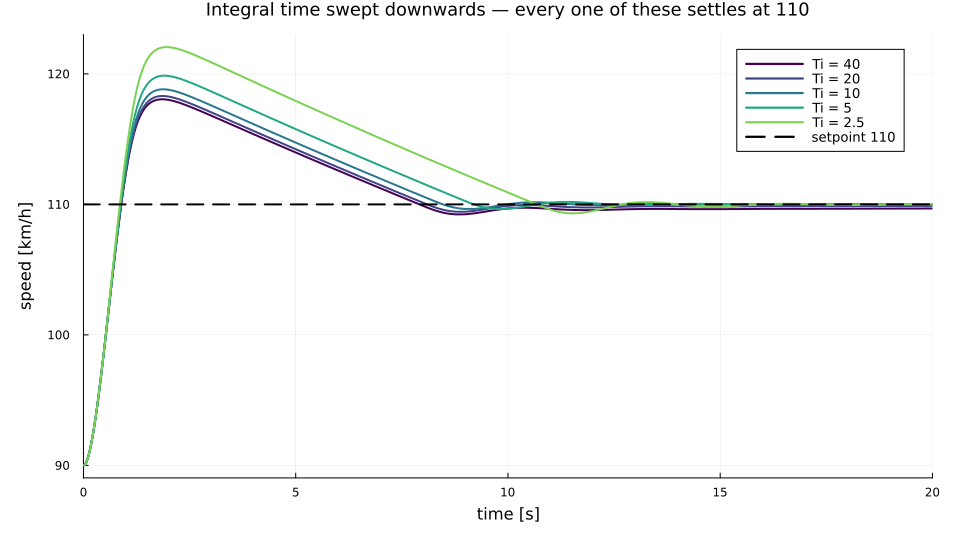

In [5]:
TIS = [40.0, 20.0, 10.0, 5.0, 2.5]

ti_family = sweep(pi_loop, "Ti", TIS)

println("  Ti [s]    overshoot    peak speed [km/h]")
for (ti, sol) in ti_family
    println("  ", rpad(ti, 8),
            "  ", rpad(string(round(overshoot(sol, SETPOINT; sig = SPEED), digits = 1), " %"), 11),
            "  ", round(maximum(signal(sol, SPEED)[2]), digits = 2))
end

plt = plot_sweep(ti_family; sig = SPEED, setpoint = SETPOINT, name = "Ti",
                 title = "Integral time swept downwards — every one of these settles at 110",
                 legend = :topright, xlims = (0, 20))
save_figure(plt, "04-ti-family")
plt

Every curve in that family reaches the setpoint, because every one of them has an integrator and
an integrator only stops at zero error. What changes is the journey: as `T_i` falls from 40 s to
2.5 s the overshoot climbs from 40% to 60% of the step, and the ringing afterwards takes longer
to die away.

So `T_i` does not trade error against no-error. It trades **how fast the offset is removed**
against **how much overshoot is spent removing it**, and there is no setting that buys both.

## 5. Where the overshoot comes from

It is tempting to file overshoot under "the loop was too aggressive", but the integral term
overshoots for a reason of its own that is worth seeing, because notebook 06 turns it into a
failure and notebook 05 into a fix.

Follow the integrator through the step.

1. **The error is large, so the sum grows quickly.** At the start of the step the error is the
   full 20 km/h and the integrator is climbing as fast as it ever will.
2. **The car reaches 110 km/h — and the integrator is now too large.** It needed to end at
   40.119 N.m. It got there while the error was still positive, and it kept going: the plot in
   section 2 peaks above 57 N.m.
3. **Zero error is not a stopping condition, it is a turning point.** At the setpoint the
   integrator stops *growing*, but it is holding 17 N.m more than the car needs, so the car is
   still accelerating. It goes past.
4. **The only way back is time spent on the far side.** The sum can only come down while the
   error is negative, which means the car has to spend time *above* the setpoint. The overshoot
   is not a side effect of unwinding the integrator — the overshoot **is** the unwinding.

Read step 4 again with notebook 06 in mind. If something prevents the integrator from being
unwound promptly — an engine already at full torque, say, so that reducing the command changes
nothing — then it keeps climbing with no way to spend it, and the excursion at the far end stops
being a percentage and starts being an accident. That is integral windup, and it is the reason
anti-windup exists.

## What this bought us

The loop arrives. It arrives at whatever setpoint it is given, against whatever load the road
puts under it, and it works out the torque that holds it there without being told anything about
the car. That is a cruise controller, and for most of a century it was a very good one.

What it bought that with is overshoot — and worse, an overshoot with a cause we can now name
precisely. The integrator ends the approach holding more torque than the car needs, because it
was still accumulating while the car was still arriving. It has no way to know the arrival is
coming.

**Notebook 05** gives it one. A third path that watches how fast the error is closing and starts
taking torque out before the error reaches zero — braking on approach instead of braking on
arrival. Three terms, three jobs: what the error is now, what it has been, and where it is going.